In [ ]:
import wandb
import pandas as pd

# Initialize W&B API
api = wandb.Api()

# Set your entity and project name
ENTITY = "ahmed-attia-mbzuai"   # W&B username or team name
PROJECT = "topological-sampler" # W&B project name

# Get all runs
runs = api.runs(f"{ENTITY}/{PROJECT}")

# Extract relevant data
runs_data = []
for run in runs:
    runs_data.append({
        "id": run.id,
        "config": run.config,  # Run configurations (parameters)
        "summary": run.summary._json_dict,  # Final metrics
    })

In [13]:
# Convert to DataFrame
df = pd.DataFrame(runs_data)

In [14]:
# df normalize config and summart columns
df = pd.concat([df.drop(['config'], axis=1), df['config'].apply(pd.Series)], axis=1)
df = pd.concat([df.drop(['summary'], axis=1), df['summary'].apply(pd.Series)], axis=1)

In [15]:
df

,id,R0,R1,R2,lr,loss,lr_Z,ndim,plot,seed,...,validation_interval,replay_buffer_prioritized,_runtime,_step,_timestamp,_wandb,l1_dist,logZ_diff,loss,states_visited
0,6v7ksj0u,0.00050,1,3,0.001,TB,0.1,2,False,0,...,100,False,62.271288,6249,1.742592e+09,{'runtime': 62},0.008229,0.008530,1.550548e-03,100000
1,dkkhfxfq,0.00001,1,3,0.001,TB,0.1,2,False,0,...,100,False,33.007496,6249,1.742592e+09,{'runtime': 33},0.023437,1.386190,8.881784e-16,100000
2,hefgkxlg,0.00010,1,3,0.001,TB,0.1,2,False,0,...,100,False,33.216374,6249,1.742592e+09,{'runtime': 33},0.023437,1.386622,7.365251e-07,100000
3,xh6oqvq8,0.00005,1,3,0.001,TB,0.1,2,False,0,...,100,False,32.425181,6249,1.742592e+09,{'runtime': 32},0.023437,1.386342,3.552714e-15,100000
4,y0is78jl,0.00100,1,3,0.001,TB,0.1,2,False,0,...,100,False,68.097109,6249,1.742592e+09,{'runtime': 68},0.004902,0.000258,2.318840e-04,100000
5,zdvsqgzy,0.00500,1,3,0.001,TB,0.1,2,False,0,...,100,False,77.979553,6249,1.742592e+09,{'runtime': 77},0.000875,0.011870,1.436720e-03,100000
6,cpmmi0m6,0.01000,1,3,0.001,TB,0.1,2,False,0,...,100,False,84.683855,6249,1.742592e+09,{'runtime': 84},0.000975,0.014977,2.670101e-04,100000
7,qsuh706x,0.10000,1,3,0.001,TB,0.1,2,False,0,...,100,False,85.593002,6249,1.742592e+09,{'runtime': 85},0.000462,0.023835,3.466130e-03,100000
8,cizrqvyi,0.05000,1,3,0.001,TB,0.1,2,False,0,...,100,False,87.839872,6249,1.742592e+09,{'runtime': 87},0.000480,0.017444,1.403629e-02,100000
9,ni1zmii6,0.00001,1,3,0.001,TB,0.1,2,False,0,...,100,False,89.653314,6249,1.742592e+09,{'runtime': 89},0.001890,0.000713,1.584934e-03,100000


In [16]:
# pick only R0, R1, R2, l1_dist, sampler columns 

df = df[['R0', 'R1', 'R2', 'l1_dist', 'sampler', "height", "ndim"]]

In [17]:
df

,R0,R1,R2,l1_dist,sampler,height,ndim
0,0.00050,1,3,0.008229,normal,8,2
1,0.00001,1,3,0.023437,normal,8,2
2,0.00010,1,3,0.023437,normal,8,2
3,0.00005,1,3,0.023437,normal,8,2
4,0.00100,1,3,0.004902,normal,8,2
5,0.00500,1,3,0.000875,normal,8,2
6,0.01000,1,3,0.000975,normal,8,2
7,0.10000,1,3,0.000462,normal,8,2
8,0.05000,1,3,0.000480,normal,8,2
9,0.00001,1,3,0.001890,topological,8,2


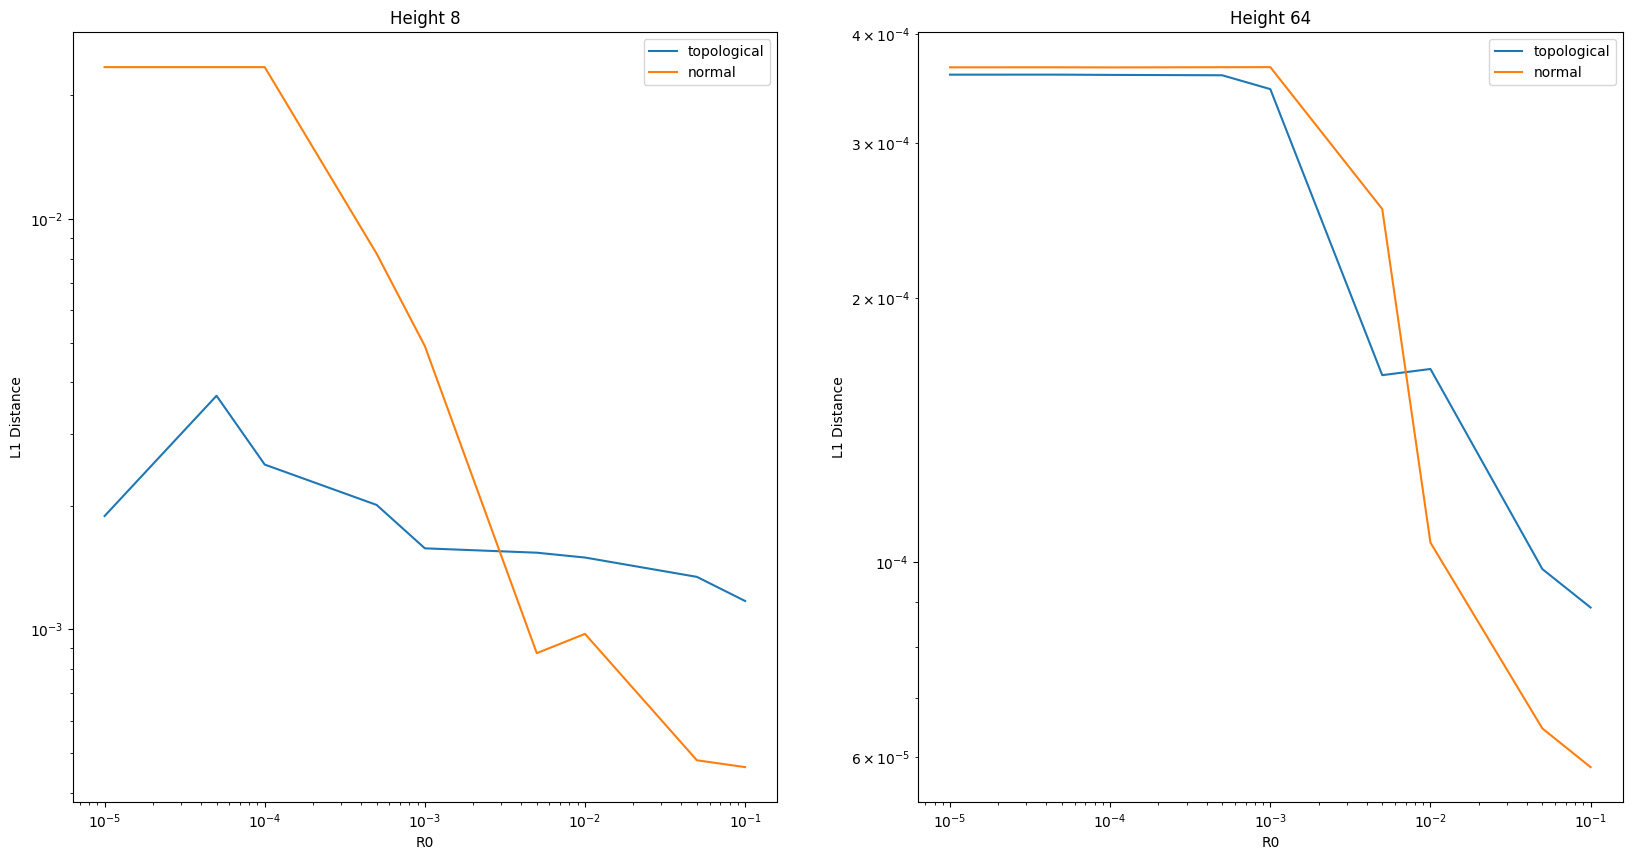

In [19]:
# plot graphs to compare changing R0 values with L1 distance for both topological and normal samplers. plot 2 different plots one for height 8 and one for height 64
import matplotlib.pyplot as plt
import seaborn as sns

topological = df[df['sampler'] == 'topological']
normal = df[df['sampler'] == 'normal']

topological_8 = topological[topological['height'] == 8]
normal_8 = normal[normal['height'] == 8]

topological_64 = topological[topological['height'] == 64]
normal_64 = normal[normal['height'] == 64]

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.lineplot(x='R0', y='l1_dist', data=topological_8, ax=ax[0], label='topological')
sns.lineplot(x='R0', y='l1_dist', data=normal_8, ax=ax[0], label='normal')
ax[0].set_title('Height 8')
# log scale for x axis
ax[0].set_xscale('log')
ax[0].set_xlabel('R0')
# log scale for y axis
ax[0].set_yscale('log')
ax[0].set_ylabel('L1 Distance')

sns.lineplot(x='R0', y='l1_dist', data=topological_64, ax=ax[1], label='topological')
sns.lineplot(x='R0', y='l1_dist', data=normal_64, ax=ax[1], label='normal')
ax[1].set_title('Height 64')
# log scale for x axis
ax[1].set_xscale('log')
ax[1].set_xlabel('R0')
# log scale for y axis 
ax[1].set_yscale('log')
ax[1].set_ylabel('L1 Distance')

plt.show()
